# 02 - Análisis Exploratorio

## Descripción del caso
El dataset original con los resultados de las pruebas escritas presentadas por aspirantes a aprendiz SENA contenía 5023 registros. Tras el proceso de limpieza de datos (ver notebook *01_proceso_de_limpieza*), la cifra de registros se redujo a 4993, eliminando 30 registros inconsistentes. El nuevo dataset, en el archivo *datos_analisis.csv*, contiene la variable Edad, inferida a partir de la variable Fecha de Nacimiento, calculada con fecha de corte al 01 de marzo de 2025.

En las tres variables o columnas de notas, la escala de calificación va de 1.0, nota más baja posible, a 5.0, nota más alta posible. La nota mínima para aprobar es **3.0**.

## Objetivo

En este notebook se analizará el perfil demográfico y académico de los aspirantes, buscando responder:

1. **¿Cómo se distribuyen los aspirantes por sexo, edad y ciudad?**
2. **¿Existen diferencias significativas en el rendimiento académico según variables demográficas?**
3. **¿Qué perfiles de aspirantes pueden identificarse?**

El análisis combinará estadísticas descriptivas, visualizaciones y generación de nuevas variables que permitan segmentar a los aspirantes para una mejor comprensión.

El dataframe *pruebas_aspirantes* contiene los datos leídos del archivo csv *datos_analisis*, donde están los datos que fueron saneados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pruebas_aspirantes = pd.read_csv('../datos/datos_analisis.csv')
print(f'Dimensiones del dataset: {pruebas_aspirantes.shape}') #Arroja las dimensiones del dataframe
print(f'Columnas: {list(pruebas_aspirantes.columns)}') #Arroja las columnas del dataframe
pruebas_aspirantes.info()
pruebas_aspirantes.head()

Dimensiones del dataset: (4993, 7)
Columnas: ['Sexo', 'Ciudad', 'Fecha de Nacimiento', 'Nota Razonamiento Cuantitativo', 'Nota Comprension Lectora', 'Nota Ingles', 'Edad']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4993 entries, 0 to 4992
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Sexo                            4992 non-null   object 
 1   Ciudad                          4993 non-null   object 
 2   Fecha de Nacimiento             4993 non-null   object 
 3   Nota Razonamiento Cuantitativo  4993 non-null   float64
 4   Nota Comprension Lectora        4993 non-null   float64
 5   Nota Ingles                     4993 non-null   float64
 6   Edad                            4993 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 273.2+ KB


,Sexo,Ciudad,Fecha de Nacimiento,Nota Razonamiento Cuantitativo,Nota Comprension Lectora,Nota Ingles,Edad
0,Femenino,Bucaramanga,1997-11-27,2.8,1.4,3.7,27
1,Masculino,Maicao,1998-03-11,2.4,2.0,2.0,26
2,Masculino,Sogamoso,1997-11-03,3.2,2.2,2.3,27
3,Femenino,Maicao,2001-09-07,2.5,1.5,3.2,23
4,Femenino,Valledupar,1996-12-22,1.2,2.0,1.2,28


## 1. Análisis descriptivo de las variables cuantitativas

In [2]:
pruebas_aspirantes[['Nota Razonamiento Cuantitativo', 'Nota Comprension Lectora', 'Nota Ingles', 
                    'Edad']].describe().round(2)

,Nota Razonamiento Cuantitativo,Nota Comprension Lectora,Nota Ingles,Edad
count,4993.00,4993.00,4993.00,4993.00
mean,2.67,2.32,2.37,22.38
std,1.05,0.80,0.91,4.19
min,1.00,1.00,1.00,16.00
25%,1.90,1.70,1.70,19.00
50%,2.50,2.20,2.20,22.00
75%,3.20,2.80,2.80,25.00
max,5.00,4.80,5.00,41.00


**Edad de los aspirantes**
- La edad promedio es de **22.38 años**, con una mediana de **22**
- La edad mínima es de **16 años** (la edad mínima para cursar un programa presencial en el SENA) y la máxima es de **41**
- El 50% de los aspirantes se concentra entre los **19 y 25 años**, coherente con el perfil típico de ingreso a formación técnica o tecnológica.
- La desviación estándar **4,19** señala una dispersión moderada
- El 25% tiene **19 años o menos**
- El 25% restante supera los **25 años**, llegando hasta adultos de **41 años**, lo que evidencia que el SENA también atrae a población en etapas de **reconversión laboral o actualización profesional** (no se ha reglamentado una edad máxima para entrar al SENA)

El perfil etario corresponde, mayoritariamente, a jóvenes adultos: hay una concentración principal en jóvenes entre los 19 y 25 años, aunque el rango total va de 16 a 41 años; sin embargo, también hay presencia relevante de edades más altas, lo que apunta a una muestra diversa en cuanto a la edad y, por consiguiente, en aspectos relacionados a esta, como, por ejemplo, el nivel educativo.


**Notas en Razonamiento Cuantitativo**
- La nota promedio es **2.67**, el más alto entre las tres variables de nota
- El 25% inferior obtiene **1.9 o menos** (muy bajo, dada la escala 1.0-5.0)
- El 25% superior alcanza **3.2 o más** (por encima de la nota mínima para aprobar), el más alto entre las variables de nota

**Notas en Inglés**
- La nota promedio es **2.37**, un tanto más alta que la de Comprensión Lectora y más baja que la de Razonamiento Cuantitativo
- El 25% inferior obtiene **1.7 o menos** (muy bajo, dada la escala 1.0-5.0)
- El 25% superior alcanza **2.8 o más**

**Notas en Comprensión Lectora**
- La nota promedio es **2.32**, el más bajo entre las tres variables de nota
- El 25% inferior obtiene **1.7 o menos** (muy bajo, dada la escala 1.0-5.0), la más baja entre las tres variables
- El 25% superior alcanza **2.8 o más**, la más baja entre las tres variables
- La nota máxima es de **4.8**, lo que indica que ningún aspirante logró obtener la nota máxima de 5.0, o, en su defecto, 4.9.

Todas las notas promedio en las tres áreas evaluadas están por debajo de 3, el umbral aprobatorio, lo que sugiere un bajo nivel general de los aspirantes.

### 1.1 Análisis general de variables de nota

En las tres variables de nota, la media es ligeramente superior a la mediana, lo que indica una distribución con sesgo positivo, posiblemente influenciada por algunos puntajes altos.

A diferencia de Inglés y Razonamiento Cuantitativo, donde hubo notas de 5.0, el puntaje más alto registrado en Comprensión Lectora es **4.8**.  
Esto confirma que ningún aspirante alcanzó el límite superior de la escala, lo que podría sugerir un menor desempeño en esta área en comparación con las otras.

Los cuartiles Q1, Q2 Y Q3 son iguales en Inglés y Comprensión Lectora, si bien en Inglés el promedio es ligeramente más alto. Esto apunta a distribuciones con estructura muy similar en ambas áreas, aunque con una ligera ventaja en el promedio de Inglés.

Las desviaciones estándar por cada área evaluada son:
- Razonamiento Cuantitativo: 1,05
- Comprensión Lectora: 0,8
- Inglés: 0,91

Dada la escala de notas de 1.0 a 5.0 (un rango de 4 puntos), los datos presentan una dispersión considerable en los resultados, especialmente en los de Razonamiento Cuantitativo. Lo anterior apunta a una alta heterogeneidad en el desempeño de los aspirantes, con presencia tanto de notas muy bajas como de otras relativamente altas en todas las áreas.

## 2. Análisis de Notas por variable Sexo

In [3]:
pruebas_aspirantes.groupby('Sexo')[[
    'Nota Razonamiento Cuantitativo',
    'Nota Comprension Lectora',
    'Nota Ingles'
]].agg(['count','mean','median','std']).round(2)

Nota Razonamiento Cuantitativo                     \
                                   count  mean median   std   
Sexo                                                          
Femenino                            2494  2.59   2.40  1.06   
Masculino                           2490  2.74   2.60  1.05   
NR/Otro                                8  2.96   2.65  1.02   

          Nota Comprension Lectora                    Nota Ingles        \
                             count  mean median   std       count  mean   
Sexo                                                                      
Femenino                      2494  2.39   2.30  0.79        2494  2.36   
Masculino                     2490  2.24   2.20  0.80        2490  2.38   
NR/Otro                          8  2.33   2.35  0.83           8  2.14   

                        
          median   std  
Sexo                    
Femenino     2.2  0.91  
Masculino    2.3  0.91  
NR/Otro      2.1  0.59

La cantidad de hombres y mujeres son similares: **2494** y **2490** respectivamente, lo que permite una comparación balanceada entre ambos grupos.

En Razonamiento Cuantitativo, los hombres presentan una media superior en **0.15** puntos respecto a las mujeres. En Comprensión Lectora ocurre lo contrario: las mujeres superan a los hombres por el mismo margen (**0.15**). En Inglés, la diferencia es mínima, de  **0.02**, por lo que puede considerarse marginal. Estas diferencias son pequeñas en el contexto de la escala de 1 a 5, lo que sugiere que no existen brechas significativas de desempeño entre hombres y mujeres.

En ambos grupos, la diferencia entre media y mediana no supera **0.2**; las asímetrías, positivas en todos los casos, son leves. No obstante, dado que la discrepancia es reducida, no se evidencia una asimetría marcada en las distribuciones.

En cuanto a quienes no respondieron o no se identificaron como de sexo femenino o masculino (NR/Otro), el tamaño muestral n es de **8**, demasiado pequeño para hacer inferencias sólidas y estadísticamente confiables. Aunque presentan el promedio más alto en Razonamiento Cuantitativo, estos resultados deben interpretarse únicamente a nivel descriptivo.

En síntesis, no se observan diferencias sustanciales en el desempeño por sexo, más allá de variaciones leves entre las notas de áreas específicas.

### 2.1 Diagrama de Caja Desempeño por Sexo

El objetivo es representar el desempeño en las áreas evaluadas por sexo respecto a la nota mínima para aprobar (3.0, representada por una línea punteada roja), mostrando la extensión del rango intercuartílico (altura de la caja) y valores atípicos.

#### 2.1.1 Desempeño por Sexo en Razonamiento Cuantitativo

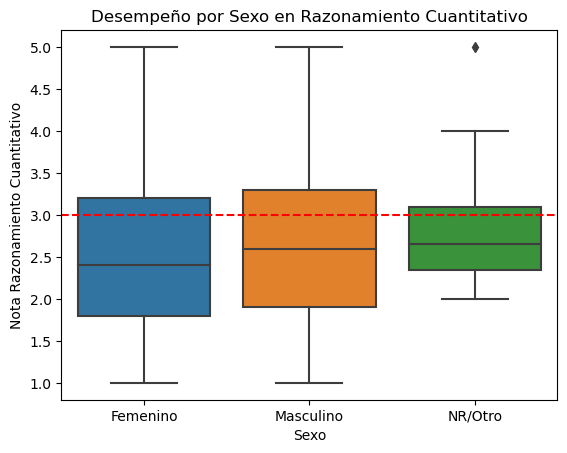

In [4]:
sns.boxplot(data=pruebas_aspirantes,
            x='Sexo',
            y='Nota Razonamiento Cuantitativo')
plt.title('Desempeño por Sexo en Razonamiento Cuantitativo')
plt.axhline(3.0, color='red', linestyle='--')
plt.show()

Se observa que los grupos Femenino y Masculino presentan una dispersión similar en las calificaciones, con valores que abarcan toda la escala (1.0–5.0) y sin presencia de valores atípicos. El rango intercuartílico es comparable en ambos casos, aunque el primer cuartil es ligeramente menor en el grupo femenino.

En todos los grupos, el tercer cuartil se sitúa alrededor o por encima del umbral de aprobación (3.0), indicando que al menos el 25% superior de las observaciones obtiene calificaciones aprobatorias.

Con los registros identificados como NR/Otro, el bigote máximo llega a 4.0 y el inferior está sobre 2.0, por encima, si bien ligeramente, del primer cuartil en los otros dos grupos; hay un outlier de 5.0.

#### 2.1.2 Desempeño por Sexo en Comprensión Lectora

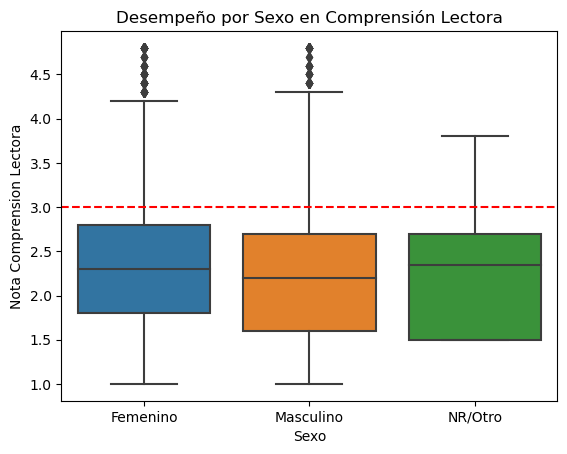

In [5]:
sns.boxplot(data=pruebas_aspirantes,
            x='Sexo',
            y='Nota Comprension Lectora')
plt.title('Desempeño por Sexo en Comprensión Lectora')
plt.axhline(3.0, color='red', linestyle='--')
plt.show()

Se observa que los grupos Masculino y Femenino tienen valores que abarcan toda la escala (1.0 a 5.0), si bien el bigote superior en ambos casos está **por debajo de 4.5**. No se observan notas que alcancen el valor máximo de la escala (5.0). En los tres grupos, más del 75% de las calificaciones se sitúan por debajo del umbral de aprobación (3.0), lo que sugiere un bajo desempeño generalizado más que una brecha significativa entre sexos.

En el grupo NR/Otro, el bigote mínimo coincide con el primer cuartil, lo que sugiere menor dispersión en los valores más bajos y ausencia de atípicos inferiores.

#### 2.1.3 Desempeño por Sexo en Inglés

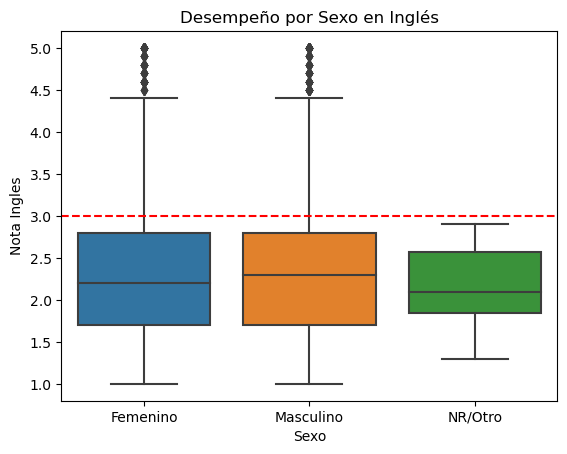

In [6]:
sns.boxplot(data=pruebas_aspirantes,
            x='Sexo',
            y='Nota Ingles')
plt.title('Desempeño por Sexo en Inglés')
plt.axhline(3.0, color='red', linestyle='--')
plt.show()

No se evidencian diferencias significativas en el desempeño en Inglés entre los grupos Femenino y Masculino, si bien la mediana en los hombres es ligeramente superior. El grupo NR/Otro presenta una mediana ligeramente inferior y menor variabilidad.

Más del 75% de las calificaciones, en los tres casos, se sitúan por debajo del umbral de aprobación (3.0).

---
En general, se observa, en los tres diagramas de caja, que la mediana está por debajo de la nota mínima para aprobar la prueba.
Las inferencias hechas de los registros identificados como NR/Otro deben tomarse con cautela, dado que el tamaño muestral es mínimo.

## 3. Análisis de notas por variables Ciudad y Región
### 3.1 Por Ciudad

In [7]:
pruebas_aspirantes.groupby('Ciudad')[[
    'Nota Razonamiento Cuantitativo',
    'Nota Comprension Lectora',
    'Nota Ingles'
]].agg(['count','mean','median','std']).round(2)

Nota Razonamiento Cuantitativo                     \
                                         count  mean median   std   
Ciudad                                                              
Aguachica                                  239  2.66    2.5  1.03   
Barrancabermeja                            248  2.74    2.6  1.10   
Bosconia                                    43  2.53    2.3  1.12   
Bucaramanga                               1002  2.63    2.5  1.02   
Girón                                      248  2.70    2.5  1.09   
Guateque                                   223  2.67    2.5  1.08   
Maicao                                     488  2.61    2.4  1.06   
Riohacha                                   503  2.64    2.5  1.05   
Sogamoso                                   738  2.73    2.5  1.10   
Tauramena                                  230  2.68    2.5  1.04   
Tibirita                                    31  2.52    2.4  1.00   
Valledupar                                 749  2.64    2.5  1.02   
Yopal                                      251  2.75    2.6  1.07   

                Nota Comprension Lectora                    Nota Ingles        \
                                   count  mean median   std       count  mean   
Ciudad                                                                          
Aguachica                            239  2.31    2.3  0.78         239  2.42   
Barrancabermeja                      248  2.28    2.2  0.80         248  2.42   
Bosconia                              43  2.50    2.6  0.72          43  2.40   
Bucaramanga                         1002  2.34    2.3  0.81        1002  2.38   
Girón                                248  2.26    2.2  0.80         248  2.40   
Guateque                             223  2.29    2.2  0.76         223  2.38   
Maicao                               488  2.28    2.2  0.77         488  2.32   
Riohacha                             503  2.28    2.2  0.82         503  2.31   
Sogamoso                             738  2.31    2.2  0.80         738  2.38   
Tauramena                            230  2.39    2.3  0.79         230  2.46   
Tibirita                              31  2.61    2.6  0.79          31  2.39   
Valledupar                           749  2.32    2.3  0.80         749  2.34   
Yopal                                251  2.35    2.2  0.85         251  2.30   

                              
                median   std  
Ciudad                        
Aguachica          2.3  0.94  
Barrancabermeja    2.3  0.98  
Bosconia           2.5  0.83  
Bucaramanga        2.3  0.89  
Girón              2.2  0.96  
Guateque           2.3  0.84  
Maicao             2.2  0.86  
Riohacha           2.2  0.87  
Sogamoso           2.2  0.97  
Tauramena          2.2  1.00  
Tibirita           2.2  0.93  
Valledupar         2.2  0.89  
Yopal              2.2  0.86

#### 3.1.1 Diagrama de Barras Distribución de Aspirantes por Ciudad

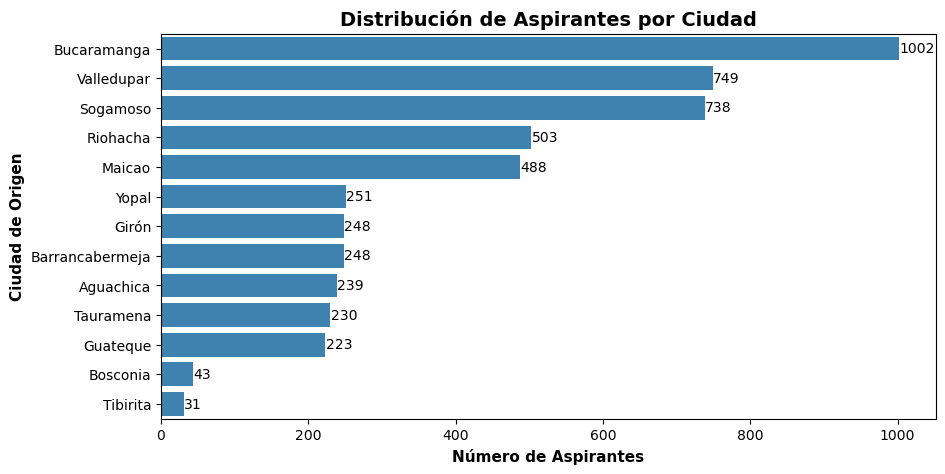

In [8]:
conteo_por_ciudad = pruebas_aspirantes['Ciudad'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(y=conteo_por_ciudad.index, x=conteo_por_ciudad.values, orient='h', order=conteo_por_ciudad.index,
             color='#2E86C1')
plt.title("Distribución de Aspirantes por Ciudad", fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel("Número de Aspirantes", fontdict={'fontsize': 11, 'fontweight': 'bold'})
plt.ylabel("Ciudad de Origen", fontdict={'fontsize': 11, 'fontweight': 'bold'})

for i, valor in enumerate(conteo_por_ciudad.values):
    plt.text(valor + 0.5, i, str(valor), va='center', fontsize=10)

plt.show()

Hay discrepancias marcadas en los tamaños muestrales entre las ciudades. Bucaramanga tiene aproximadamente un quinto de todos los registros (**1002**), mientras que Bosconia y Tibirita tienen **menos de 50**.

Por tamaño muestral o cantidad, se podrían aglutinar así:
- Grandes: Bucaramanga con **1002**, Valledupar con **749**, Sogamoso **738**
- Intermedios altos: Riohacha con **503**, Maicao con **488**
- Intermedios bajos: Yopal con **251**, Girón con **248**, Barrancabermeja con **248**, Aguachica con **239**, Tauramena con **230**, Guateque con **223**
- Pequeños: Bosconia con **43**, Tibirita con **31**

Entre más pequeña sea la muestra más inestable es la media.

En Razonamiento Cuantitativo, Yopal (**2.75**), Barrancabermeja (**2.74**) y Sogamoso (**2.73**) tienen las medias más altas. En contraste, Tibirita (**2.51**) y Bosconia (**2.53**), las ciudades con la muestra más reducida, tienen las medias más bajas. El rango de medias es de **0.24**. Las desviaciones estándar son similares (**1.0–1.12**), apuntando a una dispersión homogénea.

En Comprensión Lectora, Tibirita (**2.61**) y Bosconia (**2.49**) tienen las medias más altas; en estas dos ciudades la mediana es mayor que la media, lo que indica asimetría negativa leve; pero dado que son las ciudades con menos aspirantes, son datos a tomar con cautela interpretativa. Del otro lado, Girón (**2.26**), Maicao (**2.28**) y Riohacha (**2.28**); estas dos últimas pertenecen al mismo departamento, La Guajira, lo que podría sugerir un patrón territorial. El rango de medias es de (**0.35**), mayor que en Razonamiento Cuantitativo.

En Inglés, Tauramena (**2.45**), Barrancabermeja (**2.41**) y Aguachica (**2.40**) tienen las medias más altas, a la vez que Yopal (**2.30**), Maicao (**2.31**) y Riohacha (**2.31**) tiene las más bajas. Como en Comprensión Lectora, Riohacha y Maicao están entre las medias más bajas; de nuevo, señales de un patrón regional. Esta es la única variable donde las ciudades con tamaño muestral más reducido, Bosconia y Tibirita, no están presentes en la parte alta o baja de las medias. En este caso, el rango de medias es **0.15**, el más bajo, apuntando a un desempeño más homogéneo en esta área, entre las ciudades mencionadas.

Los rangos de medias en los tres escenarios (**0.24, 0.35, y 0.15**) son relativamente bajos en comparación con la escala total de 1 a 4.

En síntesis, las diferencias entre ciudades existen, pero no son extremas. Comprensión Lectora es la variable con mayor heterogeneidad territorial, mientras que Inglés es la más estable entre ciudades, si bien con notas promedio muy bajas. La brecha territorial es más marcada en Comprensión Lectora que en Razonamiento o Inglés. Además, predomina una ligera asimetría positiva en la mayoría de distribuciones, lo que sugiere la presencia de algunos puntajes altos que elevan la media en varias ciudades.

---
Las ciudades con tamaños muestrales pequeños presentan resultados más extremos (en Bosconia, hay asimetría negativa, si bien leve); esto exige cautela en su interpretación.

Que, por ejemplo, Riohacha y Maicao, ciudades de un mismo departamento, aparezcan en un extremo de los datos (en este caso, en las medias más bajas en Comprensión Lectora e Inglés), subraya la necesidad de estudiar también el comportamiento de las notas por región.

### 3.2 Por Región

Para llevar a cabo el análisis por región, se crea una columna denominada Región donde las ciudades se agrupan de la siguiente forma:

- Región **La Guajira-Norte de Cesar**: Riohacha, Maicao, Valledupar y Bosconia
- Región **Santander-Sur de Cesar**: Bucaramanga, Barrancabermeja, Girón y Aguachica (esta última, más cercana a Bucaramanga, capital de Santander, que a Valledupar, capital de Cesar, por lo que se agrupa con la primera)
- Región **Boyacá-Casanare**: Sogamoso, Guateque, Yopal, Tauramena y Tibirita (esta última hace parte del departamento de Cundinamarca, pero está ubicada en la frontera con Boyacá)

Esta división por regiones se sustenta en los departamentos a los que pertenecen las ciudades de origen de los aspirantes.

In [9]:
region = {
    "Riohacha": "La Guajira-Norte de Cesar", "Maicao": "La Guajira-Norte de Cesar",
    "Valledupar": "La Guajira-Norte de Cesar", "Bosconia": "La Guajira-Norte de Cesar",
    "Bucaramanga": "Santander-Sur de Cesar", "Barrancabermeja": "Santander-Sur de Cesar",
    "Girón": "Santander-Sur de Cesar", "Aguachica": "Santander-Sur de Cesar",
    "Sogamoso": "Boyacá-Casanare", "Yopal": "Boyacá-Casanare", "Tauramena": "Boyacá-Casanare",
    "Guateque": "Boyacá-Casanare", "Tibirita": "Boyacá-Casanare"
}

pruebas_aspirantes["Region"] = pruebas_aspirantes["Ciudad"].map(region)
pruebas_aspirantes.head()

,Sexo,Ciudad,Fecha de Nacimiento,Nota Razonamiento Cuantitativo,Nota Comprension Lectora,Nota Ingles,Edad,Region
0,Femenino,Bucaramanga,1997-11-27,2.8,1.4,3.7,27,Santander-Sur de Cesar
1,Masculino,Maicao,1998-03-11,2.4,2.0,2.0,26,La Guajira-Norte de Cesar
2,Masculino,Sogamoso,1997-11-03,3.2,2.2,2.3,27,Boyacá-Casanare
3,Femenino,Maicao,2001-09-07,2.5,1.5,3.2,23,La Guajira-Norte de Cesar
4,Femenino,Valledupar,1996-12-22,1.2,2.0,1.2,28,La Guajira-Norte de Cesar


In [10]:
pruebas_aspirantes.groupby('Region')[[
    'Nota Razonamiento Cuantitativo',
    'Nota Comprension Lectora',
    'Nota Ingles'
]].agg(['count','mean','median','std']).round(2)

Nota Razonamiento Cuantitativo                     \
                                                   count  mean median   std   
Region                                                                        
Boyacá-Casanare                                     1473  2.71    2.5  1.08   
La Guajira-Norte de Cesar                           1783  2.63    2.4  1.04   
Santander-Sur de Cesar                              1737  2.66    2.5  1.04   

                          Nota Comprension Lectora                     \
                                             count  mean median   std   
Region                                                                  
Boyacá-Casanare                               1473  2.33    2.3  0.80   
La Guajira-Norte de Cesar                     1783  2.30    2.2  0.79   
Santander-Sur de Cesar                        1737  2.32    2.3  0.80   

                          Nota Ingles                     
                                count  mean median   std  
Region                                                    
Boyacá-Casanare                  1473  2.38    2.2  0.94  
La Guajira-Norte de Cesar        1783  2.33    2.2  0.87  
Santander-Sur de Cesar           1737  2.39    2.3  0.92

La región con mayor número de aspirantes es La Guajira–Norte de Cesar (**1783**), seguida por Santander–Sur de Cesar (**1737**); Boyacá–Casanare presenta una participación ligeramente menor (**1473**). No obstante, las tres regiones muestran tamaños muestrales comparables, lo que permite realizar comparaciones balanceadas, sin sesgos importantes derivados de diferencias extremas.

En Razonamiento Cuantitativo, Boyacá–Casanare presenta el promedio más alto (**2.71**), seguido por Santander–Sur de Cesar (**2.66**) y La Guajira–Norte de Cesar (**2.63**). Aunque las diferencias no son amplias, sugieren una ligera ventaja relativa de Boyacá–Casanare en esta competencia.

En Comprensión Lectora, las diferencias entre regiones son mínimas, con promedios prácticamente equivalentes, lo que sugiere un desempeño homogéneo en esta área. El rango de medias es **0.03**.

En Inglés, aunque Santander–Sur de Cesar presenta el promedio más alto en Inglés (**2.39**), la diferencia frente a Boyacá–Casanare (**2.38**) es marginal y probablemente no significativa. La Guajira–Norte de Cesar (**2.33**) muestra un promedio ligeramente inferior en comparación con las otras dos regiones.

En síntesis, la diferencia regional es más marcada en Razonamiento Cuantitativo, si bien el rango de medias allí es de **0.08**. La región **La Guajira-Norte de Cesar** tiene los promedios más bajos en las tres áreas. Por otra parte, las desviaciones estándar son similares entre regiones, lo que indica niveles comparables de dispersión en las notas y sugiere que las diferencias observadas en los promedios no parecen estar influenciadas por una mayor variabilidad en alguna región específica.

#### 3.2.1 Diagramas de Barras Apiladas - Proporción Aspirantes Reprobados vs Aprobados por Región
El objetivo es representar la proporción de notas en las tres áreas evaluadas por región. Para ello, se definen las siguientes categorías:

- Deficiente (menores a 2.0)
- Reprobado (entre 2.0 y menor a 3.0)
- Aprobado Básico (entre 3.0 y 3.5)
- Aprobado Alto (mayor a 3.5)


In [11]:
condiciones_rc = [
    pruebas_aspirantes['Nota Razonamiento Cuantitativo'] < 2,
    (pruebas_aspirantes['Nota Razonamiento Cuantitativo'] >= 2) &
    (pruebas_aspirantes['Nota Razonamiento Cuantitativo'] <= 3),
    (pruebas_aspirantes['Nota Razonamiento Cuantitativo'] >= 3) &
    (pruebas_aspirantes['Nota Razonamiento Cuantitativo'] <= 3.5),
    pruebas_aspirantes['Nota Razonamiento Cuantitativo'] > 3.5
]

condiciones_cl = [
    pruebas_aspirantes['Nota Comprension Lectora'] < 2,
    (pruebas_aspirantes['Nota Comprension Lectora'] >= 2) &
    (pruebas_aspirantes['Nota Comprension Lectora'] <= 3),
    (pruebas_aspirantes['Nota Comprension Lectora'] >= 3) &
    (pruebas_aspirantes['Nota Comprension Lectora'] <= 3.5),
    pruebas_aspirantes['Nota Comprension Lectora'] > 3.5
]

condiciones_i = [
    pruebas_aspirantes['Nota Ingles'] < 2,
    (pruebas_aspirantes['Nota Ingles'] >= 2) &
    (pruebas_aspirantes['Nota Ingles'] <= 3),
    (pruebas_aspirantes['Nota Ingles'] >= 3) &
    (pruebas_aspirantes['Nota Ingles'] <= 3.5),
    pruebas_aspirantes['Nota Ingles'] > 3.5
]

categorias = ['Deficiente', 'Reprobado', 'Aprobado básico', 'Aprobado alto']


##### 3.2.1.1 Proporción Aspirantes Aprobados vs Reprobados Razonamiento Cuantitativo

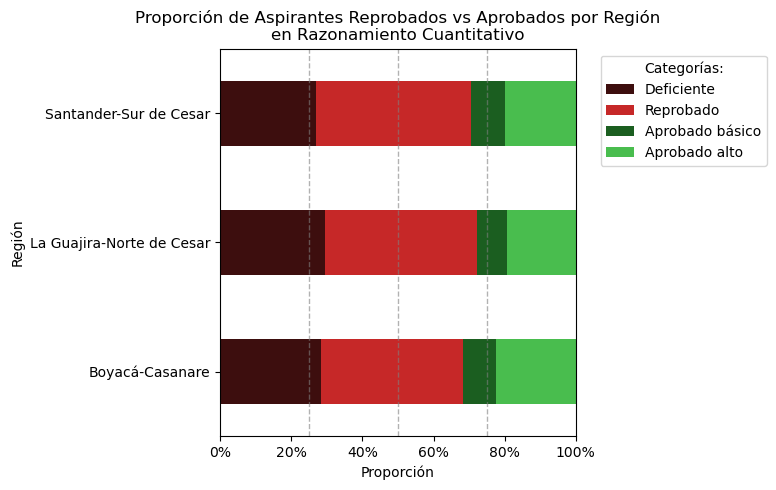

In [12]:
resultado_rc = np.select(condiciones_rc, categorias)

tabla_rc = (
    pruebas_aspirantes
    .assign(Resultado=resultado_rc)
    .groupby('Region')['Resultado']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

tabla_rc = tabla_rc[['Deficiente', 'Reprobado','Aprobado básico','Aprobado alto']]

fig, ax = plt.subplots(figsize=(8,5))

tabla_rc.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=["#3D0E0E", '#C62828','#1B5E20', "#49BD4E"] 
)

ax.set_title('Proporción de Aspirantes Reprobados vs Aprobados por Región\nen Razonamiento Cuantitativo')
ax.set_xlabel('Proporción')
ax.set_ylabel('Región')
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
for x in [0.25, 0.50, 0.75]:
    ax.axvline(
        x=x,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.6
    )
ax.legend(
    title='Categorías:',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

Se observa que en las tres regiones el porcentaje de aspirantes reprobados en Razonamiento Cuantitativo **supera el 65%**, esto teniendo en cuenta que los promedios en esta área son más altos que en Inglés y Comprensión Lectora.

La región La Guajira-Sur del Cesar tiene el mayor porcentaje de notas reprobadas (**más de 70%**) y la franja más reducida de notas aprobadas básicas.

El porcentaje de notas deficientes es menor en la región Santander-Sur de Cesar (**alrededor de 25%**), a la vez que en las otras dos regiones se ubica alrededor del 30%. 

El porcentaje más grande de notas aprobadas altas lo tiene la región Boyacá-Casanare (**más de 20%**).

##### 3.2.1.2 Proporción Aspirantes Aprobados vs Reprobados Comprensión Lectora

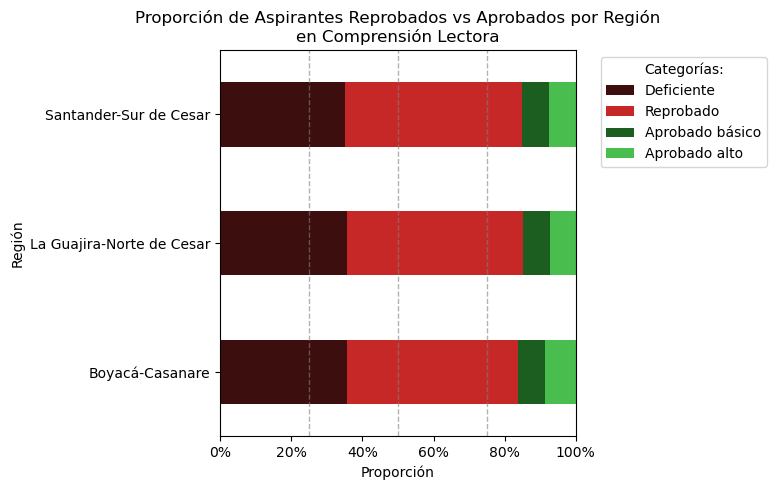

In [13]:
resultado_cl = np.select(condiciones_cl, categorias)

tabla_cl = (
    pruebas_aspirantes
    .assign(Resultado=resultado_cl)
    .groupby('Region')['Resultado']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

tabla_cl = tabla_cl[['Deficiente', 'Reprobado','Aprobado básico','Aprobado alto']]

fig, ax = plt.subplots(figsize=(8,5))

tabla_cl.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=["#3D0E0E", '#C62828','#1B5E20', "#49BD4E"]
)

ax.set_title('Proporción de Aspirantes Reprobados vs Aprobados por Región\nen Comprensión Lectora')
ax.set_xlabel('Proporción')
ax.set_ylabel('Región')
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
for x in [0.25, 0.50, 0.75]:
    ax.axvline(
        x=x,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.6
    )
ax.legend(
    title='Categorías:',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

Se observa que en las tres regiones el porcentaje de aspirantes reprobados en Comprensión Lectora **supera el 80%**, a la vez que el porcentaje de notas deficientes **supera el 35%**. 

La sección porcentual de aspirantes con notas aprobatorias básicas y altas es más amplia en la región Boyacá-Casanare, pero las diferencias con las otras regiones es mínima.

El desempeño bajo está más marcado en esta área, y es general.

##### 3.2.1.3 Proporción Aspirantes Aprobados vs Reprobados Inglés

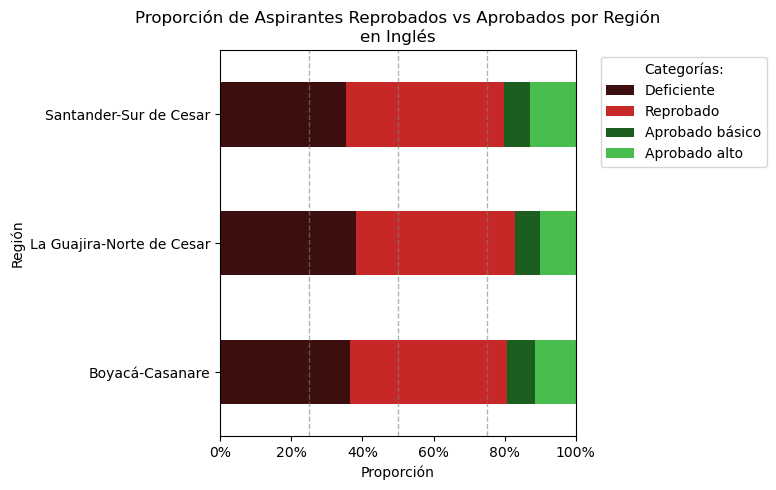

In [14]:
resultado_i = np.select(condiciones_i, categorias)

tabla_i = ( #Fijar la proporción
    pruebas_aspirantes
    .assign(Resultado=resultado_i)
    .groupby('Region')['Resultado']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

tabla_i = tabla_i[['Deficiente', 'Reprobado','Aprobado básico','Aprobado alto']]

fig, ax = plt.subplots(figsize=(8,5))

tabla_i.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=["#3D0E0E", '#C62828','#1B5E20', "#49BD4E"]  # rojo, verde claro, verde oscuro
)

ax.set_title('Proporción de Aspirantes Reprobados vs Aprobados por Región\nen Inglés')
ax.set_xlabel('Proporción')
ax.set_ylabel('Región')
ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
for x in [0.25, 0.50, 0.75]:
    ax.axvline(
        x=x,
        color='gray',
        linestyle='--',
        linewidth=1,
        alpha=0.6
    )
ax.legend(
    title='Categorías:',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

Se observa que, en Inglés, la región Santander-Sur de Cesar tiene el mayor porcentaje de notas aprobadas básicas y altas (**más del 20%**). 

En contraste, la región La Guajira-Norte de Cesar presenta mayor proporción de notas deficientes y reprobadas (**más de 80%**). 

El porcentaje de notas deficientes está **sobre el 35%** en La Guajira-Norte de Cesar y Boyacá-Casanare.

---
En síntesis, el desempeño en las tres áreas en todas las regiones es bajo, pero las falencias están más marcadas en Comprensión Lectora e Inglés. La región La Guajira-Norte de Cesar tiene la mayor proporción de aspirantes reprobados en todas las áreas.

## 4 Análisis de notas por variable Edad
Las edades de los aspirantes están comprendidas entre los 16 y 41 años, los valores máximo y mínimo respectivamente. Para efectuar un análisis práctico, es necesario aglutinar las edades en intervalos, definidos en la nueva columna **Rango Edad**. 

El criterio que se toma para aglutinarlos en intervalos son los cuartiles, que serán su punto de corte, dado que, de este modo, cada grupo contendría aproximadamente el 25% de los datos. Es una decisión que evita la arbitrariedad, ya que está basada en la distribución de las edades.

Los rangos de edad son:

- 16–19 años
- 20–22 años
- 23–25 años
- 26–41 años

In [15]:
pruebas_aspirantes["Rango Edad"] = pd.cut(
    pruebas_aspirantes["Edad"],
    bins=[15, 19, 22, 25, 41],
    labels=["16-19 años", "20-22 años", "23-25 años", "26-41 años"]
)

pruebas_aspirantes.head()

,Sexo,Ciudad,Fecha de Nacimiento,Nota Razonamiento Cuantitativo,Nota Comprension Lectora,Nota Ingles,Edad,Region,Rango Edad
0,Femenino,Bucaramanga,1997-11-27,2.8,1.4,3.7,27,Santander-Sur de Cesar,26-41 años
1,Masculino,Maicao,1998-03-11,2.4,2.0,2.0,26,La Guajira-Norte de Cesar,26-41 años
2,Masculino,Sogamoso,1997-11-03,3.2,2.2,2.3,27,Boyacá-Casanare,26-41 años
3,Femenino,Maicao,2001-09-07,2.5,1.5,3.2,23,La Guajira-Norte de Cesar,23-25 años
4,Femenino,Valledupar,1996-12-22,1.2,2.0,1.2,28,La Guajira-Norte de Cesar,26-41 años


In [16]:
pruebas_aspirantes.groupby('Rango Edad')[[
    'Nota Razonamiento Cuantitativo',
    'Nota Comprension Lectora',
    'Nota Ingles'
]].agg(['count','mean','median','std']).round(2)

Nota Razonamiento Cuantitativo                     \
                                    count  mean median   std   
Rango Edad                                                     
16-19 años                           1530  2.70    2.5  1.04   
20-22 años                           1364  2.71    2.5  1.05   
23-25 años                            908  2.72    2.5  1.08   
26-41 años                           1191  2.52    2.4  1.04   

           Nota Comprension Lectora                    Nota Ingles        \
                              count  mean median   std       count  mean   
Rango Edad                                                                 
16-19 años                     1530  2.28    2.2  0.78        1530  2.39   
20-22 años                     1364  2.33    2.3  0.80        1364  2.41   
23-25 años                      908  2.32    2.2  0.78         908  2.39   
26-41 años                     1191  2.34    2.3  0.83        1191  2.27   

                         
           median   std  
Rango Edad               
16-19 años    2.3  0.92  
20-22 años    2.3  0.90  
23-25 años    2.2  0.92  
26-41 años    2.2  0.90

El rango de edad más numeroso es el de 16-19 años (**1530**), seguido por 20-22 años (1364). El grupo menos representado es el de 23-25 años (**908**). Pese a estas diferencias, todos los rangos cuentan con tamaños muestrales suficientes para realizar comparaciones válidas.

En Razonamiento Cuantitativo, la diferencia de medias entre los tres rangos con edades más jóvenes (16 a 25 años), cuyos promedios oscilan entre **2.70** y **2.72**, es de **0.02**; las medias entre estos tres rangos son muy similares, indicando que el desempeño es practicamente equivalente entre estos tres rangos. El rango 26-41 años, el de mayor edad, tiene una media ligeramente más baja, con **2.52**; esto implica una ligera disminución del desempeño en grupos de mayor edad.

En Comprensión Lectora, el rango 16-19 años, el de menor edad, epresenta la media más baja (**2.28**). En contraste, el rango 26-41 años tiene la media más alta (**2.34**). Lo anterior apunta a un desempeño ligeramente más alto cuanto mayor sea la edad, si bien las diferencias entre rangos son ínfimas.

En Inglés, los rangos más jóvenes (16-25 años) presentan medias cercanas entre **2.39** y **2.41**. El grupo de mayor edad (26-41 años) muestra un leve descenso (**2.27**). El patrón es similar al de Razonamiento Cuantitativo, con un ligero desempeño menor en aspirantes mayores a 25 años.

---

La media es ligeramente superior a la mediana en todos los casos, indicando una leve asimetría positiva en las distribuciones.

Las desviaciones estándar son bajas y similares en cada área, sin diferencias relevantes entre sí, lo que indica una dispersión similar de las notas dentro de cada rango de edad.

Se observan pequeñas variaciones según el área: mientras Razonamiento Cuantitativo e Inglés muestran una ligera disminución con la edad, Comprensión Lectora tiende a mejorar levemente.

En síntesis, ninguna de las medias por rango de edad, en las tres áreas evaluadas, superó el umbral de 3.0, la nota mínima para aprobar, **lo que sugiere un desempeño general bajo que no parece estar fuertemente asociado al factor edad**.

### 4.1 Diagrama Circular Área con Mejor Desempeño por Rango de Edad

El objetivo es exponer en qué área obtiene cada aspirante su mejor nota, para luego evidenciar, por medio del diagrama circular, la distribución por rango de edad.

Para hacerlo, se crea la columna Mejor Area, que será una variable categórica inferida de la comparación entre las tres variables de notas.

In [17]:
areas = [ 'Nota Razonamiento Cuantitativo', 'Nota Comprension Lectora', 'Nota Ingles']

pruebas_aspirantes["Mejor Area"] = pruebas_aspirantes[areas].idxmax(axis=1)

pruebas_aspirantes["Mejor Area"] = pruebas_aspirantes["Mejor Area"].replace({
    'Nota Razonamiento Cuantitativo': 'R. Cuantitativo',
    'Nota Comprension Lectora': 'Lectura',
    'Nota Ingles': 'Inglés'
})

pruebas_aspirantes.head()

,Sexo,Ciudad,Fecha de Nacimiento,Nota Razonamiento Cuantitativo,Nota Comprension Lectora,Nota Ingles,Edad,Region,Rango Edad,Mejor Area
0,Femenino,Bucaramanga,1997-11-27,2.8,1.4,3.7,27,Santander-Sur de Cesar,26-41 años,Inglés
1,Masculino,Maicao,1998-03-11,2.4,2.0,2.0,26,La Guajira-Norte de Cesar,26-41 años,R. Cuantitativo
2,Masculino,Sogamoso,1997-11-03,3.2,2.2,2.3,27,Boyacá-Casanare,26-41 años,R. Cuantitativo
3,Femenino,Maicao,2001-09-07,2.5,1.5,3.2,23,La Guajira-Norte de Cesar,23-25 años,Inglés
4,Femenino,Valledupar,1996-12-22,1.2,2.0,1.2,28,La Guajira-Norte de Cesar,26-41 años,Lectura


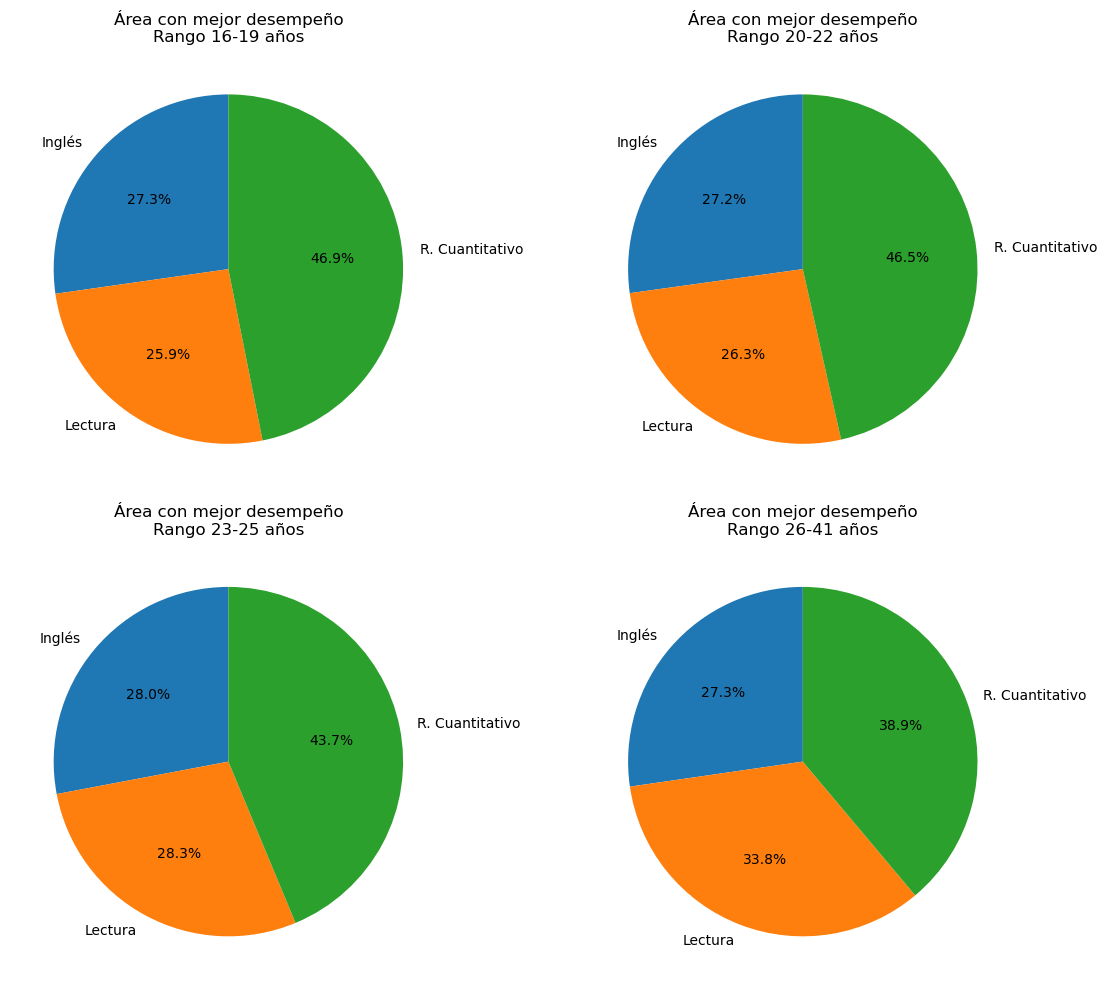

In [18]:
tabla_rgxedad = pd.crosstab(
    pruebas_aspirantes["Rango Edad"],
    pruebas_aspirantes["Mejor Area"],
    normalize="index"
) * 100

fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for i, rango in enumerate(tabla_rgxedad.index):
    
    axes[i].pie(
        tabla_rgxedad.loc[rango],
        labels=tabla_rgxedad.columns,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f"Área con mejor desempeño\nRango {rango}")

plt.tight_layout()
# plt.savefig("../imagenes/areas_edades.png")
plt.show()

En los cuatro escenarios, la mayor proporción de aspirantes obtiene su mejor resultado en Razonamiento Cuantitativo, lo que indica que esta área concentra el desempeño relativo más alto. No obstante, esta proporción disminuye progresivamente con la edad, pasando de aproximadamente 46.9% en los rangos más jóvenes a 38.9% en el rango de 26-41 años.

En contraste, en Comprensión Lectora se evidencia una tendencia ascendente con la edad, aumentando desde cerca de 26% en el rango 16-19 años hasta 33.8% en el rango de mayor edad. Esto sugiere que el desempeño relativo en esta área tiende a ganar terreno entre aspirantes de mayor edad.

El caso del área de Inglés presenta un comportamiento más bien estable: la proporción de aspirantes cuyo mejor resultado se encuentra en esta área permanece prácticamente constante entre rangos de edad, alrededor del 27-28%, lo que indica una distribución estable del desempeño relativo.

---

Los resultados anteriores sugieren que el perfil de fortalezas en las áreas evaluadas varía ligeramente con la edad. 

Los aspirantes más jóvenes tienden a destacar más en Razonamiento cuantitativo, los de mayor edad muestran una distribución más equilibrada y una mayor presencia relativa de Comprensión Lectora.

En síntesis, en lo que respecta al desempeño, Razonamiento Cuantitativo domina en rangos de edades jóvenes, Comprensión Lectora gana peso con la edad, a la vez que Inglés permanece estable.

- - -
- - -

## Respuestas a Preguntas Planteadas en el Objetivo
### Pregunta 1: **¿Cómo se distribuyen los aspirantes por sexo, edad y ciudad?**

**Por sexo**, la distribución es balanceada. Dentro de los 4993 registros del dataset, hay **2494** mujeres y **2490** hombres. Solo **8** aspirantes están registradas bajo una identidad sexual no binaria, y **1** no tiene ningún valor válido (ver punto 5.3 del notebook *01_proceso_de_limpieza*).

**Por edad**, al aglutinarse los aspirantes en rangos de edad, (ver punto 4 del presente notebook), **1530** aspirantes tienen entre 16 y 19 años, **1364** tienen entre 20 y 22 años, **908** tienen entre 23 y 25 años, y **1191** tienen entre 26 y 41 años. Pese a que la edad máxima es de 41 años, aproximadamente tres cuartas partes de los aspirantes tienen 25 años o menos (ver punto 1 del presente notebook). 

**Por ciudad**, **1002** aspirantes son de la ciudad de **Bucaramanga**, aproximadamente un quinto del total. Girón y Barrancabermeja, otras ciudades del departamento de Santander, tienen **496** aspirantes entre ellas. Hay presencia considerable de aspirantes de ciudades del norte del país: **1783** son de Valledupar, Riohacha, Maicao y Bosconia. **1473** aspirantes son de ciudades de los departamentos de Boyacá y Casanaer; Sogamoso, con **738** aspirantes, resalta en la región (ver punto 3 del presente notebook).

### Pregunta 2: **¿Existen diferencias significativas en el rendimiento académico según variables demográficas?**

**Por sexo**, las diferencias entre hombres y mujeres son leves. A los hombres les va mejor en Razonamiento Cuantitativo y a las mujeres en Comprensión Lectora, pero la brecha es de **0.15** en la nota promedio en ambos grupos, mínima teniendo en cuenta la escala de 1 a 5. En Inglés la distancia se acorta aún más, la diferencia es ínfima (ver punto 2 del presente notebook). 

**Por edad**, el desempeño es pobre en todos los rangos de edad en Inglés. Cuanto más joven es el aspirante se observan mejores notas en Razonamiento Cuantitativo, pero no es una tendencia marcada. El desempeño en Comprensión Lectora mejora al aumentar la edad de los aspirantes, pero la distancia con los rangos de edad más joven es marginal; con todo, a los aspirantes les suele ir mejor en esta área cuanto más longevos son (ver punto 4.1 del presente notebook).

**Por región**, las ciudades del norte, pertenecientes a la región La Guajira-Sur de Cesar (ver punto 3.2.1.1 del presente notebook), presentan el desempeño más bajo en las tres áreas evaluadas. La mayor proporción de notas aprobadas se ve en Razonamiento Cuantitativo en todas las regiones (ver punto 3.2 del presente notebook), a la vez que el desempeño es pobre en Inglés y Comprensión Lectora.

En conclusión, el desempeño es bajo a nivel general, y estos resultados pobres no parecen estar determinados de forma marcada por ninguna de las variables demográficas presentes en el dataset. Sin embargo, se observan discrepancias leves en algunos casos, como los antes referidos.


### Pregunta 3: **¿Qué perfiles de aspirantes pueden identificarse?**



El perfil del aspirante a aprendiz típico, dada la información del dataset analizado, es una persona joven de entre 19 y 22 años, con igual probabilidad de ser hombre o mujer, y proviene de una ciudad grande o intermedia del noroccidente del país. Tiene un desempeño aceptable en Razonamiento Cuantitativo, pero le cuesta destacarse en Comprensión Lectora e Inglés.